# SSH model with the Liouville Class

### Author : Mathieu Desmarais (python version of the mathematica code of Eric Bitner)
#### Date: 08-06-2026

The goal is to rewrite in python this code that extact third-order nonlinear optical response in the Liouville Space. The model is the SSH model.
This code will be use for starting point for the Spin-Orbite Model for the CuGeO3. 


The LiouvilleSpectroscopySolver module computes the third-order nonlinear optical response (S3) of crystalinne solid-state system. Instead of employing computationally heavy time-domain numerical integration (such as QuDpy), this class evaluates the macroscopic polarization anlytically in the frequency domain. 

The core architecture relies on mapping the d-dimensional Hilbert space into a d^2-dimensional Liouville space. By treating the density matrix as a vector and operators as superoperators, the time-evolution integrals required by perturbation theory are transformed into direct algebraic matrix inversions (Green's functions/resolvents). The solver is completely vectrorized over the brillouin zone (Nk points) via multidimensional tensor algebra, allowing it to scale seamlessly from simple 2-band tight binding Hamiltonian to complex multi-band spin-orbit systems.

### Hilbert Space Preparation (feed_model())

Before computing the dynamics, the raw physics defined in the site/orbital basis must be transformed into the energy basis where optical transitions are well-defined.

#### Eignendecomposition

The solver receives the raw Hamiltonian H(k) and the total currentoperator$J(k) = \partial H / \partial k$ as $(N_k, d, d)$ tensors. It first solvens the time-independent Schrodinger equation for all k-points simultaneously.

$$H(k) |u_n(k)\rangle = E_n(k) |u_n(k)\rangle$$

this yields the diagonalized Hamiltonian H_eigen and the unitary transformation matrix V containing the eigenvectors. 

#### The Rotating Wave Approximation (RWA)

The current operator J (representing the light-matter interaction in the velocity gauge) is rotated into the energy basis: $J_{eigen} = V^\dagger J V$.

To isolate specific pathways in the multidimensional spectra and eliminate rapidly oscillating, non-energy-conserving termes, the rotating Wave approximation is applied. The operator is Stricly partitioned into: 

- J^+ (Absorption): Contains only the stricly upper-triangular elements of $J_{eigen}$ (j>i). It represents a transition upward in energy, corresponding to the annihilation of a phonon. 

- J^- (Emission) : Contains only the stricly lower-triangular element (j < i)   It represents a transition downward in energy, corresponding to the creation of a photon 

### The Liouville Space Formalism

To describe open quantum systems (including phenomenological dephasing and population relaxation), the system must be described by a density matrix rho.

#### Vectorization
Liouville space is constructed by "flattening" the d X d density matrix rho, into a column vector | rho > of dimension $d^2 \times 1$

#### Superoperators (_spre and _spost)

Standard Hilbert space operators acting on rho from the left or the right become superoperators (matrices of dimension $d^2 \times d^2$) acting on the vector $|\rho\rangle\rangle$.
Using the Kronecker product $\otimes$, the left- and right-acting superoperators are defined as :


- Left action: $A\rho \longrightarrow (\mathbb{I} \otimes A)|\rho\rangle\rangle \equiv \mathcal{A}_{L}|\rho\rangle\rangle$

- Right action: $\rho A \longrightarrow (A^T \otimes \mathbb{I})|\rho\rangle\rangle \equiv \mathcal{A}_{R}|\rho\rangle\rangle$

In the solver, _spre and _spost compute these superoperator for all k-points concurrently using optimized numpy.einsum tensor contractions. 

### The Effective Liouvillian and Dissipation

The dynamics of the system are governed by the Liouville-von Neumann equation with Lindblad dissipation: 

$$\frac{\partial \rho}{\partial t} = -i[H, \rho] + \mathcal{L}_{diss}(\rho)$$

#### Coherent Evolution

The commutator is expressed as a Liouvillian superoperator 
$$\mathcal{L}_{coh} = \mathcal{H}_L - \mathcal{H}_R$$

#### Lindblad Dissipation (_get_lindblad)

For any collapse operator C (e.g. $J^-$ for population relaxation) with a rate $\gamma$, the Lindblad dissipator is mapped to Liouville space:

$$\mathcal{D}[C]\rho = \gamma \left( C \rho C^\dagger - \frac{1}{2} C^\dagger C \rho - \frac{1}{2} \rho C^\dagger C \right)$$


Using the superoperator definitions, the exact algebraic form is constructed: 

$$\mathcal{L}_{diss} = \gamma \left( \mathcal{C}_L \mathcal{C}^\dagger_R - \frac{1}{2}(\mathcal{C}^\dagger \mathcal{C})_L - \frac{1}{2}(\mathcal{C}^\dagger \mathcal{C})_R \right)$$


The total effective generator of the dynamics is $\mathcal{L}_{eff} = \mathcal{L}_{coh} + i\mathcal{L}_{diss}$ (The factor of i balances the extraction of the complexpahses during propagation).

## Frquency-Domain Propagation (Green's functions)

In nonlinear spectrocopy, the system interacts with three laser pulses, separated by time delays $t_1$ (coherence), $\tau_2$ (Population), and $t_3$ (detection coherence)

#### Coherence Periods ($t_1$ and $t_3$)
Rather than propagating $e^{-i\mathcal{L}t}$ numerically, a Laplace-Fourier transform is applied to move to the frequency domain. The time-integral of the response function yields the Resolvent (or Liouville Space Green's Function):

$$G(\omega) = \frac{1}{\pm\omega \mathbb{I} - \mathcal{L}_{eff} + i\eta \mathbb{I}}$$

- $\omega$ is the probe/pump frequency
- $\eta$ is a phenomenological homogeneous broadening factor ensuring the polesare slightly off the real axis, preventing singularities and defininf the intrinsic linewidth. 
- Matrix inversion (np.linalg.inv) of this $d^2 \times d^2$ matrix provides the exact analytical solution for the coherence evolutions. 

#### Population Period ($\tau_2$)

During the waiting time $\tau_2$, the optical fields are off ($\omega$ = 0). the system is propagated in the time domain: 

$$\mathcal{G}_2(\tau_2) = e^{-i\mathcal{L}(0)\tau_2}$$

to optimize this over massive k-grids, the solver diagonalize $\mathcal{L}(0)$ and exponetiates its eigenvalues, bypassing slow numerical integration routines. 


## Feynman Pathways and Macroscopic Trace

The third-order polarization is the sum of specific sequences of light-matter interactions. The solver computes the three primary pathways: Ground State Bleaching (GSB), stimulated Emission (SE), and Excited State Absorption (ESA). 

#### The Matrix Multiplication Chain

the pathways are assembled by chaining the propagators and interaction superoperators chornologically (from right to left). For instance, a GSB sequence inthe rephasing quadrant ($-k_1 + k_2 + k_3$) is computed as:

$$\text{Path}_{GSB} = G_3(\omega_3) \mathcal{J}^+_L \mathcal{G}_2(\tau_2) \mathcal{J}^+_R G_1(-\omega_1) \mathcal{J}^-_R |\rho_{eq}\rangle\rangle$$
(Note: $G_1$ is evaluated at $-\omega_1$ for rephasing, denoting conjugate coherence evolution).

#### The Trace Operation

To extract the observable macroscopic polarization, the trace of the final density matrix is taken. In Liouville space, taking the trace corresponds to a dot product with an identity vector $\langle\langle \mathbb{I} |$: 

$$S^{(3)}_{GSB} = \langle\langle \mathbb{I} | \mathcal{J}^{out}_L | \text{Path}_{GSB} \rangle\rangle$$
Where $\mathcal{J}^{out}_L = \mathcal{J}^+_L + \mathcal{J}^-_L$.

Finally, the paths are summed ($GSB + SE - ESA$), and integrated over the entire Brillouin zone (summation over $N_k$) to yield the distinct 2D complex spectral maps for the specified phase-matching conditions. 



### packages and modules import

In [1]:
from LiouvilleSpectroscopy import LiouvilleSpectroscopySolver
from LiouvilleSpectroscopy import SpectroscopyPlotter
import numpy as np
import matplotlib.pyplot as plt
import time

### Model function related

In [2]:
def build_raw_tensors(k_array, t1,t2):
    N = len(k_array)
    d = 2 # ou 3, 4, etc.
    
    H_raw = np.zeros((N, d, d), dtype=complex)
    H_raw[:, 0, 1] = t1 + t2 * np.exp(-1j * k_array)
    H_raw[:, 1, 0] = t1 + t2 * np.exp(1j * k_array)

    J_raw = np.zeros((N, d, d), dtype=complex)
    J_raw[:, 0, 1] = -1j * t2 * np.exp(-1j * k_array)
    J_raw[:, 1, 0] =  1j * t2 * np.exp(1j * k_array)

    return H_raw, J_raw


#### Building Hamiltonian


In [3]:
TOTAL_KPOINTS = 10
k_array = np.linspace(-np.pi, np.pi, TOTAL_KPOINTS)
dk = k_array[1] - k_array[0]


w_list = np.linspace(-1.5, 1.5, 100) 
w_list2 = np.linspace(0.5,1.5)
tau2_test = 3.0  # Updated according to your file
    
params_topo = {"t1": 1.0, "t2": 1.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}
params_triv = {"t1": 1.0, "t2": 0.5, "Eta": 0.05, "T": 0.01, "mu": 0.0, "omegaLO": 1.0, "lambda": 0.1}

t1_topo, t2_topo = params_topo["t1"], params_topo["t2"]
t1_triv, t2_triv = params_triv["t1"], params_triv["t2"]


H_topo,J_raw_topo= build_raw_tensors(k_array, t1_topo,t2_topo)

H_triv,J_raw_triv= build_raw_tensors(k_array, t1_triv,t2_triv)



# Main


In [4]:
# 1. Instantiate the solver with your physical parameters
solver_topo = LiouvilleSpectroscopySolver(params_topo)

# 2. Inject the NumPy tensors previously generated with QuTiP
start = time.time()
solver_topo.feed_model(H_triv, J_raw_topo)
print(f"feed_model finished in {time.time() - start:.4f}s")

# 3. Add the Lindblad dissipation operators (e.g., band relaxation)
# The solver knows these are full tensors along the k-axis
c_ops = [(solver_topo.J_minus, 0.05)] 
solver_topo.set_dissipation(c_ops)

start = time.time()
# 4. Extract all the spectra at once
spectres = solver_topo.generate_2D_spectra(w_list, tau2=3.0, k_array=k_array)
print(f"generate_2D_spectra finished in {time.time() - start:.4f}s")

# Your data is ready for the visualizer!
S3_pure_rephasing_topo = spectres["rephasing"]
S3_pure_unrephasing_topo = spectres["unrephasing"]


# =========================================================
# Trivial Phase Calculation
# =========================================================

# 1. Instantiate the solver with your physical parameters
solver_triv = LiouvilleSpectroscopySolver(params_triv)

# 2. Inject the NumPy tensors previously generated with QuTiP
solver_triv.feed_model(H_triv, J_raw_triv)

# 3. Add the Lindblad dissipation operators (e.g., band relaxation)
# The solver knows these are full tensors along the k-axis
c_ops = [(solver_triv.J_minus, 0.05)] 
solver_triv.set_dissipation(c_ops)

# 4. Extract all the spectra at once
spectres = solver_triv.generate_2D_spectra(w_list, tau2=3.0, k_array=k_array)

# Your data is ready for the visualizer!
S3_pure_rephasing_triv = spectres["rephasing"]
S3_pure_unrephasing_triv = spectres["unrephasing"]

feed_model finished in 0.0005s
generate_2D_spectra finished in 10.4653s


#### Spectrum


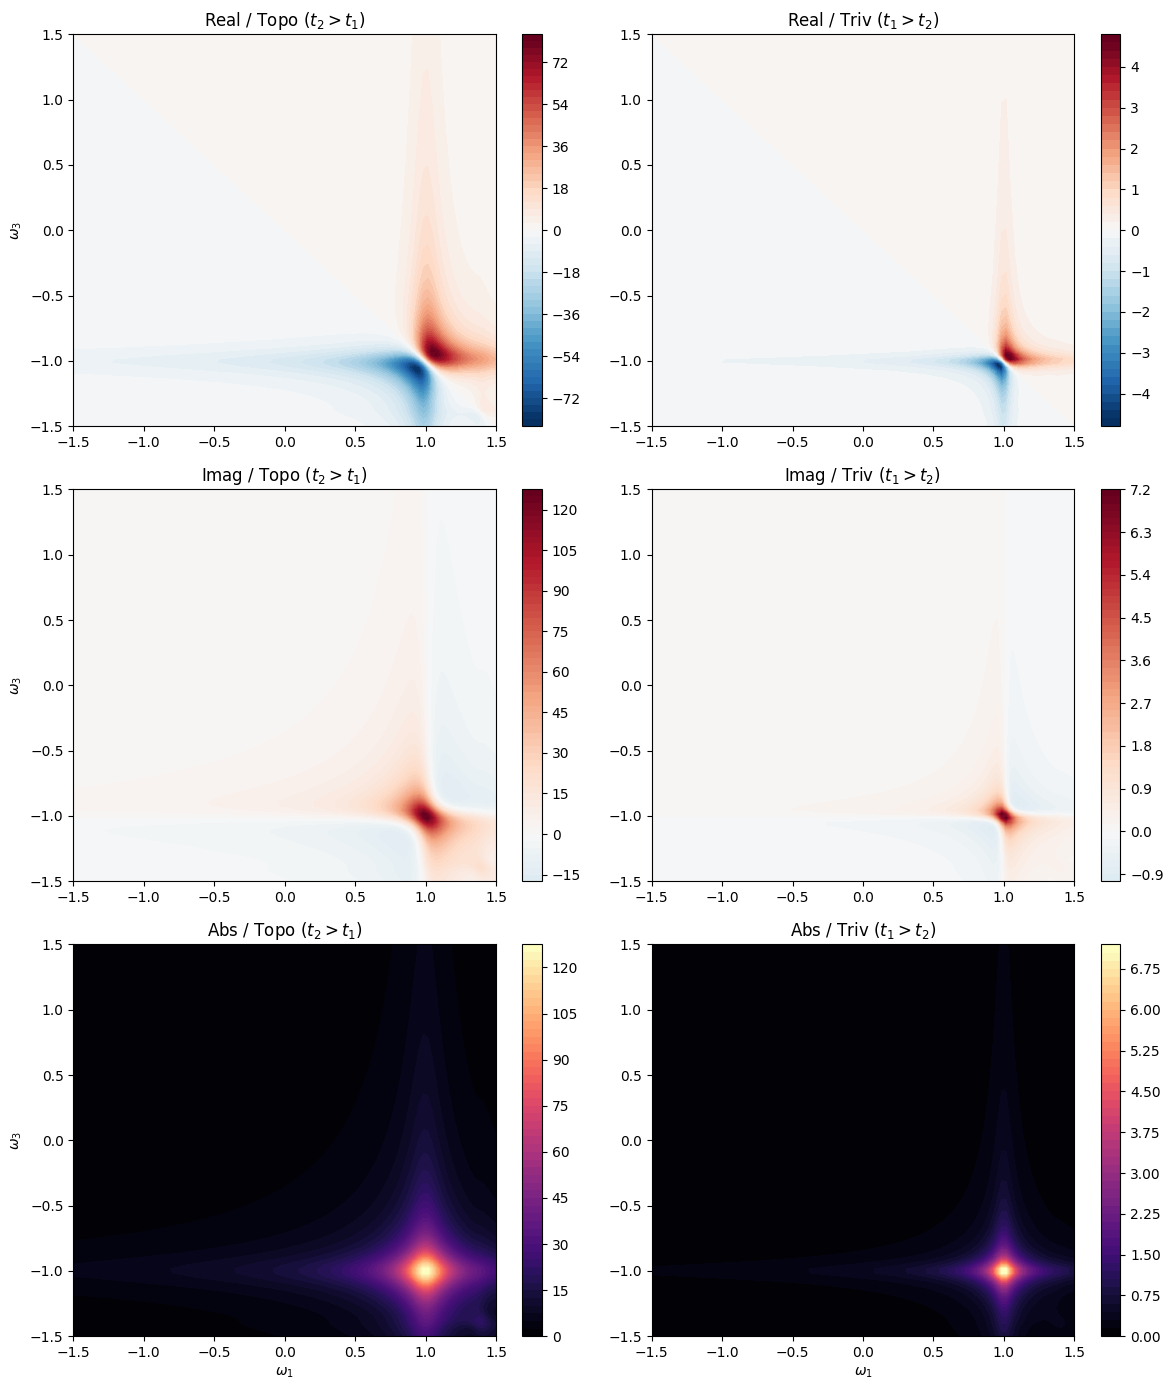

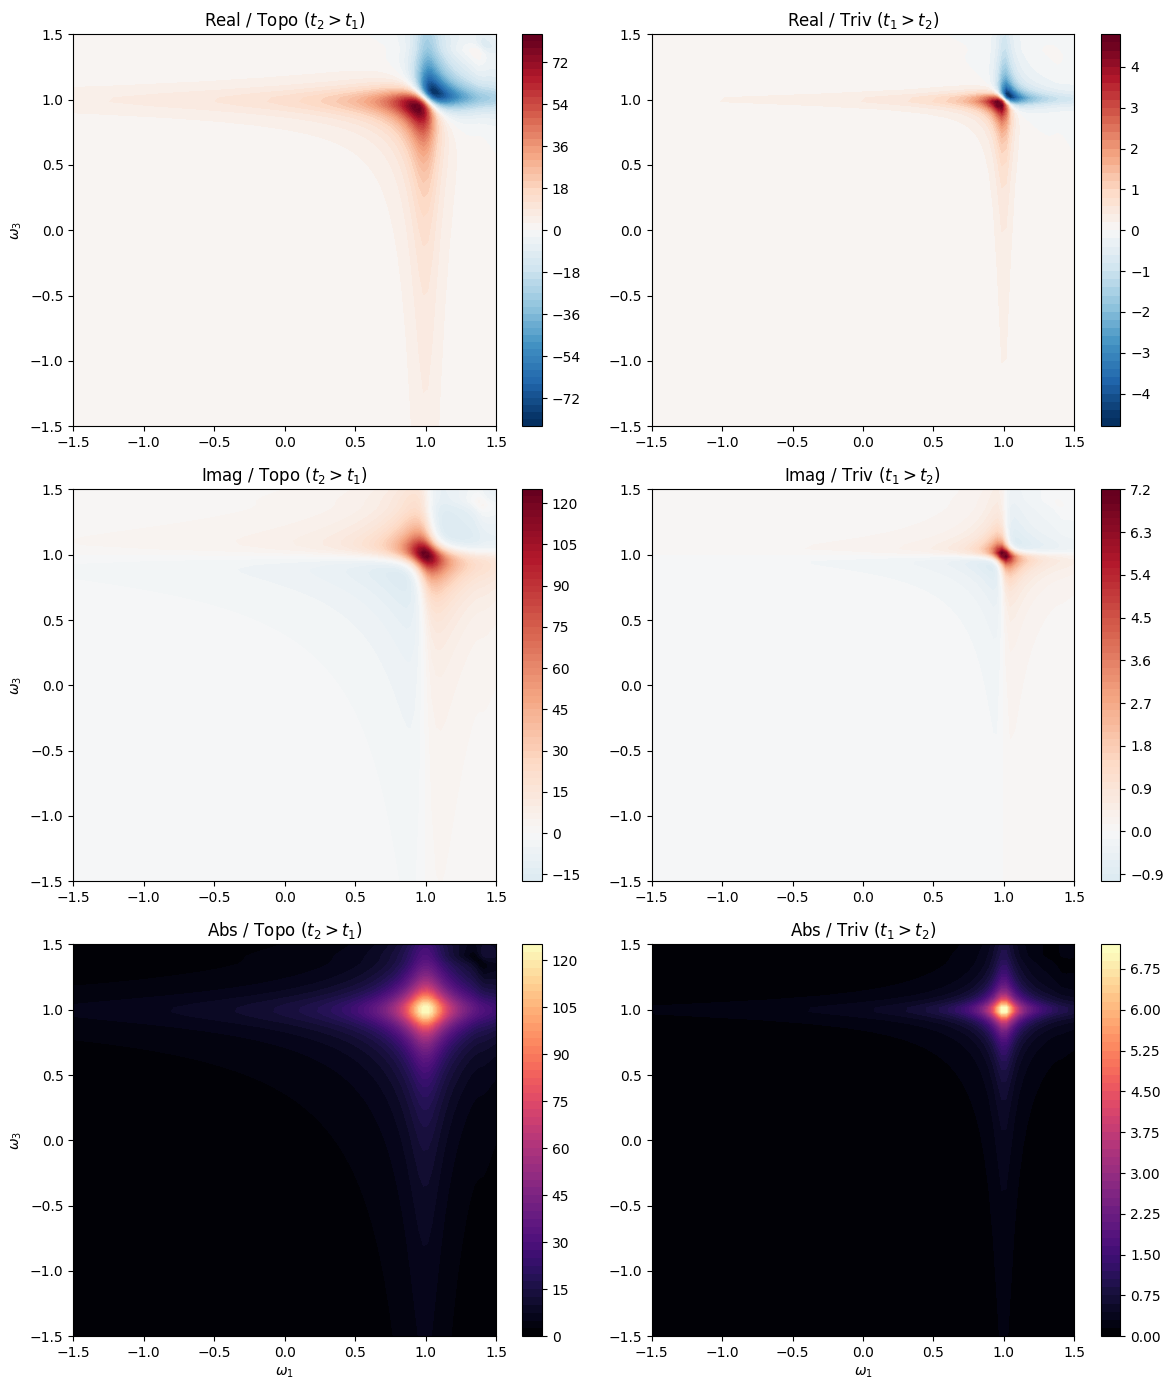

In [5]:
Spec = SpectroscopyPlotter(w_list)


Spec.plot_spectrum(S3_pure_rephasing_topo,S3_pure_rephasing_triv)

Spec.plot_spectrum(S3_pure_unrephasing_topo,S3_pure_unrephasing_triv)


#### Random Functions